In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from functools import partial

from deepqmc.postprocess.workdir import read_workdir 
from deepqmc.postprocess.mc_utils import clipped_mean_and_sampling_error
from deepqmc.postprocess.ansatz_utils import instantiate_predefined_ansatz, load_parameters

from deepqmc.molecule import Molecule
from deepqmc.hamil import MolecularHamiltonian
from deepqmc.sampling import MetropolisSampler, DecorrSampler, combine_samplers
from deepqmc.sampling.electron_sample_initializers import AtomCenteredElectronInitializer, ShellBasedDistribution
from deepqmc.types import PhysicalConfiguration

# Ground state energy of LiH

The simplest possible DeepQMC experiment: optimize the ground-state wave function of LiH and evaluate the energy of the optimized ansatz.

### Training

Firstly an optimization run for LiH is commenced using the command line interface directly from the notebook.

In [ ]:
!deepqmc hydra.run.dir=ground_state_lih_workdir ansatz=psiformer task.pretrain_steps=1000 task.steps=10000 task.electron_batch_size=2048

[2026-07-13 18:37:32.992] INFO:deepqmc.app: Entering application
[2026-07-13 18:37:33.366] INFO:deepqmc.app: Process 0 running on otter
[2026-07-13 18:37:33.366] INFO:deepqmc.app: Running on 1 NVIDIA GEFORCE RTX 3090 with 1 process
[2026-07-13 18:37:33.366] INFO:deepqmc.app: Will work in ground_state_lih_workdir
[2026-07-13 18:37:33.418] DEBUG:deepqmc.app: Running with code version: facba19e
[2026-07-13 18:37:35.264] DEBUG:deepqmc.train: Setting up metric_logger...
[2026-07-13 18:37:35.269] DEBUG:deepqmc.train: Setting up h5_logger...
[2026-07-13 18:37:40.577] INFO:deepqmc.wf.base: Number of model parameters: 1610498
[2026-07-13 18:37:40.666] INFO:deepqmc.train: Pretraining wrt. baseline wave function
[2026-07-13 18:37:40.921] INFO:deepqmc.pretrain.pyscfext: Running HF...
[2026-07-13 18:37:41.064] INFO:deepqmc.pretrain.pyscfext: HF energy: -7.9519715386625505
[2026-07-13 18:37:41.064] INFO:deepqmc.pretrain.pyscfext: Dump PySCF checkpoint to ground_state_lih_workdir/training/pyscf_chkpt

The training logs are written to result.h5:

In [ ]:
!h5ls -r ground_state_lih_workdir/training/result.h5

/                        Group
/local_energy            Group
/local_energy/max        Dataset {10000/Inf, 1, 1}
/local_energy/mean       Dataset {10000/Inf, 1, 1}
/local_energy/min        Dataset {10000/Inf, 1, 1}
/local_energy/samples    Dataset {10000/Inf, 1, 1, 1, 2048}
/local_energy/std        Dataset {10000/Inf, 1, 1}
/psi                     Group
/psi/samples             Group
/psi/samples/log         Dataset {10000/Inf, 1, 1, 1, 2048}
/psi/samples/sign        Dataset {10000/Inf, 1, 1, 1, 2048}
/sampling                Group
/sampling/log_psi        Group
/sampling/log_psi/mean   Dataset {10000/Inf, 1, 1}
/sampling/log_psi/std    Dataset {10000/Inf, 1, 1}


Here we are interested in the training energy to investigate convergence. 

One way to load the data from the `result.h5` file is with the `read_workdir` method from the `deepqmc.postprocess` submodule.
The method takes the path to the workdir of the training run and a list of the  keys to extract (here the mean energy per iteration).

The shape of the logs is `[#iterations, #molecules, #states]`. Retrieving the mean, the electron walker dimension and the GPU dimension are already summed over. Since this is a single-point simulation of the ground state the first and the second axis can be removed, retaining only a 1D array with the mean energy per training iteration.

In [ ]:
data, train_steps = read_workdir(Path('ground_state_lih_workdir'), ['local_energy/mean'])
print(data['local_energy/mean'].shape)

training_energies=data['local_energy/mean'].squeeze()

(10000, 1, 1)


We can now plot the training energy and investigate the convergence to the reference value.

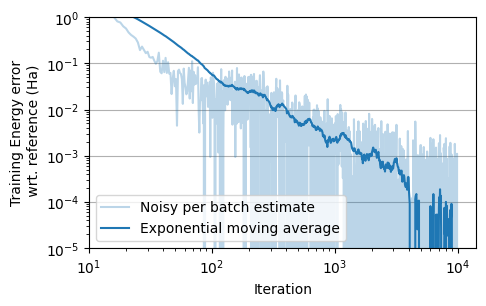

In [ ]:
LiH_ref = -8.070548 # 10.1016/S0009-2614(00)00303-1
log_sampled_iterations = jnp.unique(jnp.logspace(1,4,1000, dtype=int)-1)
log_sampled_energies = training_energies[log_sampled_iterations]
ewm = pd.Series(log_sampled_energies - LiH_ref).ewm(span=50)
plt.figure(figsize=(5, 3))
plt.grid(axis='y', which='major')
plt.plot(log_sampled_iterations, log_sampled_energies - LiH_ref, alpha=0.3, c='C0', label='Noisy per batch estimate')
plt.plot(log_sampled_iterations, ewm.mean(), label='Exponential moving average', c='C0')
plt.xscale('log')
plt.yscale('log')
plt.xlim(10)
plt.ylim(1e-5, 1e-0)
plt.xlabel('Iteration')
plt.ylabel('Training Energy error\n wrt. reference (Ha)')
plt.legend()
plt.show()


### Evaluation

Next we evaluate the trained wave function ansatz. To that end we use the `evaluate` task with the restdir set to the `training` folder in the working directory of the previous run.

In [ ]:
!deepqmc task=evaluate hydra.run.dir=ground_state_lih_evaluate_workdir task.restdir=ground_state_lih_workdir/training

[2026-07-13 20:09:19.298] INFO:deepqmc.app: Entering application
[2026-07-13 20:09:19.651] INFO:deepqmc.app: Process 0 running on otter
[2026-07-13 20:09:19.651] INFO:deepqmc.app: Running on 1 NVIDIA GEFORCE RTX 3090 with 1 process
[2026-07-13 20:09:19.651] INFO:deepqmc.app: Will work in ground_state_lih_evaluate_workdir
[2026-07-13 20:09:19.752] DEBUG:deepqmc.app: Running with code version: facba19e
[2026-07-13 20:09:21.274] INFO:deepqmc.app: Found original config file in ground_state_lih_workdir/training, from checkpoint LAST
[2026-07-13 20:09:22.040] DEBUG:deepqmc.train: Setting up metric_logger...
[2026-07-13 20:09:22.045] DEBUG:deepqmc.train: Setting up h5_logger...
[2026-07-13 20:09:22.050] INFO:deepqmc.train: Start evaluation
[2026-07-13 20:09:26.341] INFO:deepqmc.train: Equilibrating sampler...
equilibrate sampler:   8%|▌      | 78/1000 [00:17<03:22,  4.55it/s, tau=(0.154)]
[2026-07-13 20:09:43.477] INFO:deepqmc.train: Start evaluation
[2026-07-13 20:09:54.084] INFO:deepqmc.tra

To obtain the final energy estimate of the DeepQMC simulation all local energies are loaded from the h5 file and the mean and sampling error of the evaluation run are determined. 
Loading the local energy for all samples the logs now have the shape `[#iterations, #gpus, #molecules, #states, #walkers]`, where `#walkers` is the number of MCMC chains per GPU and per molecule, that is the `electron_batch` size on each GPU. 
Again the irrelevant dimensions can be removed with squeeze and an array of the shape `[#iterations, #walkers]` remains. 

In [ ]:
data, steps = read_workdir(Path('ground_state_lih_evaluate_workdir'), ['local_energy/samples'])
print(data['local_energy/samples'].shape)

evaluation_local_energies = data['local_energy/samples'].squeeze()

(1000, 1, 1, 1, 2048)


From the samples the mean and the statistical sampling error can be computed.
Note that clipping of the local energies should be avoided, since it can easily introduce a bias since the local energies are not distributed symmetrically around the mean. However, there are scenarios where gentle clipping can be useful, i.e. when computing relative energies.

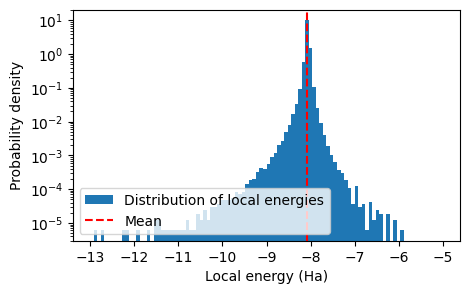

In [ ]:
plt.figure(figsize=(5, 3))

plt.hist(evaluation_local_energies.flatten(), bins=100, range=(-13,-5), density=True, label='Distribution of local energies')
plt.axvline(evaluation_local_energies.mean(), color='red', linestyle='--', label='Mean')
plt.yscale('log')
plt.xlabel('Local energy (Ha)')
plt.ylabel('Probability density')
plt.legend(loc='lower left')
plt.show()

In [ ]:
mean, error, clipping_ratio = clipped_mean_and_sampling_error(evaluation_local_energies, lower=-np.inf, upper=np.inf)
print(f"Final evaluation energy: {mean:.5f} ± {error:.5f} Ha")
print(f"Final energy error wrt. to reference: {(mean - LiH_ref)*10**3:.1f} mHa")

Final evaluation energy: -8.07050 ± 0.00004 Ha
Final energy error wrt. to reference: 0.0 mHa


The evaluated energy matches the energy estimate from the training and is within about 1 mHa of the reference energy.

### Investigate at the wave function

Here we exemplarily evaluate the trained wave function ansatz on a line through the nuclei and another electron, with the remaining electrons being placed at random.

In [ ]:
hamil = MolecularHamiltonian(mol=Molecule.from_name('LiH'))
wave_function = instantiate_predefined_ansatz('psiformer', hamil).apply
params = load_parameters(Path('ground_state_lih_workdir/training/chkpt-1000.pt'), state=0)

In [ ]:
random_electron_config = AtomCenteredElectronInitializer(atom_centered_distribution=ShellBasedDistribution())(jax.random.PRNGKey(42), hamil.mol.charges, hamil.ns_valence, hamil.mol.coords, hamil.n_up, hamil.n_down)

n = 1000
line = jnp.linspace(-2, 5, n) 
elec_conf = random_electron_config[None]
elec_conf = elec_conf.at[:, 0:1, :].set(0)
elec_conf = elec_conf.at[:, 1, 0].set(2)

electron_line = elec_conf.repeat(n, axis=0)
electron_line = electron_line.at[:, 0, 0].set(line)

phys_conf = PhysicalConfiguration(r = electron_line, R = hamil.mol.coords[None].repeat(n, axis=0), mol_idx=jnp.zeros((n,)))

In [ ]:
sign_psis, log_psis = jax.vmap(wave_function, in_axes=[None,0])(params, phys_conf)
e_loc, stats = jax.vmap(hamil.local_energy(wave_function), in_axes=[None, None, 0])(None, params, phys_conf)

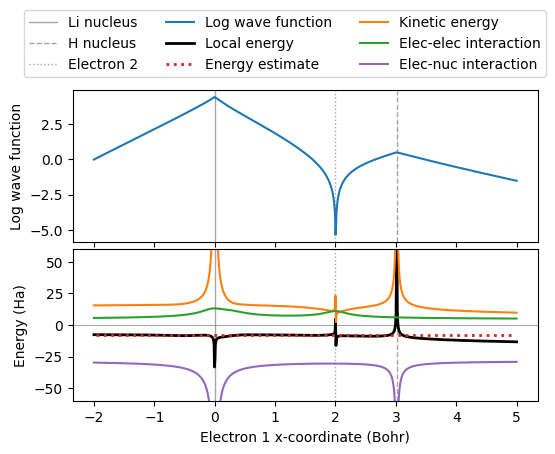

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)

for ax in (ax1, ax2):
    ax.axvline(hamil.mol.coords[0, 0], color='gray', linestyle='-', lw=1, alpha=0.7, label='Li nucleus')
    ax.axvline(hamil.mol.coords[1, 0], color='gray', linestyle='--', lw=1, alpha=0.7, label='H nucleus')
    ax.axvline(2, color='gray', linestyle=':', lw=1, alpha=0.7, label='Electron 2')

ax1.plot(line, log_psis, c='C0', label='Log wave function')
ax1.tick_params(labelbottom=False)
ax1.set_ylabel('Log wave function')

ax2.axhline(0, color='gray', lw=0.5)
ax2.plot(line, e_loc, label='Local energy', c='k', lw=2)
ax2.axhline(mean,0.05, 0.95, color='C3', label='Energy estimate', ls=':', lw=2)
ax2.plot(line, stats['hamil/E_kin'], label='Kinetic energy', c='C1')
ax2.plot(line, stats['hamil/V_el'], label='Elec-elec interaction', c='C2')
ax2.plot(line, stats['hamil/V_loc'], label='Elec-nuc interaction', c='C4')
ax2.set_xlabel('Electron 1 x-coordinate (Bohr)')
ax2.set_ylabel('Energy (Ha)')
ax2.set_ylim(-60, 60)

handles, labels = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), ncol=3, loc=(0.043,0.83))
plt.subplots_adjust(hspace=0.05,top=0.8)
plt.show()

### Manually sample the wave function

Here we sample the wave function. In principle this can easily be achieved though the CLI, but this example is here to get exposed to the low-level API of DeepQMC.

In [ ]:
metropolis_sampler = partial(MetropolisSampler, 
                            sample_initializer=AtomCenteredElectronInitializer(
                                atom_centered_distribution=ShellBasedDistribution()),
                        )
elec_sampler = combine_samplers(samplers=[DecorrSampler(length=20), metropolis_sampler], hamil=hamil, wf=wave_function)

In [ ]:
rng_init, rng_sample = jax.random.split(jax.random.PRNGKey(42), 2)
sampler_state = elec_sampler.init(rng_init, params, n=1000, R=hamil.mol.coords)

@jax.jit
def sample_wf(rng_sample, sampler_state):
    sampler_state, phys_conf, stats = elec_sampler.sample(rng_sample, sampler_state, params, R=hamil.mol.coords)
    return sampler_state, phys_conf, stats

electon_positions = []
for i in range(500):
    sampler_state, phys_conf, stats = sample_wf(jax.random.fold_in(rng_sample, i), sampler_state)
    electon_positions.append(phys_conf.r)
electon_positions = jnp.stack(electon_positions)

### Electron density

The sampled electron positions directly estimate the electron density ρ(r) = ⟨Σᵢ δ(r - rᵢ)⟩: pooling all electrons, walkers and sampling steps together and histogramming their positions in the plane containing the two nuclei gives a 2D map of where the electrons are found.

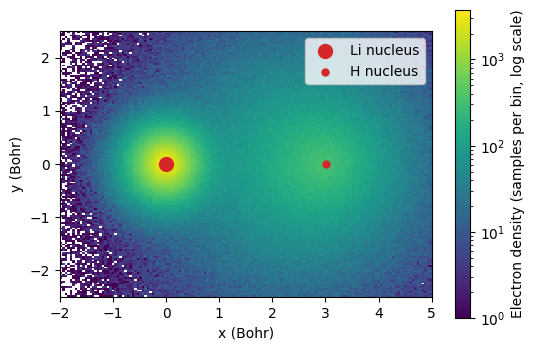

In [ ]:
from matplotlib.colors import LogNorm

positions = electon_positions.reshape(-1, 3)

plt.figure(figsize=(6, 4))
h = plt.hist2d(
    positions[:, 0], positions[:, 1],
    bins=150, range=[[-2, 5], [-2.5, 2.5]],
    norm=LogNorm(), cmap='viridis',
)
plt.colorbar(h[3], label='Electron density (samples per bin, log scale)')
plt.scatter(hamil.mol.coords[0, 0], hamil.mol.coords[0, 1], color='C3', marker='o', s=100, label='Li nucleus')
plt.scatter(hamil.mol.coords[1, 0], hamil.mol.coords[1, 1], color='C3', marker='.', s=100, label='H nucleus')
plt.xlabel('x (Bohr)')
plt.ylabel('y (Bohr)')
plt.gca().set_aspect('equal')
plt.legend(loc='upper right')
plt.show()

### Conclusion

We have simulated the ground state wave function of the LiH molecule and estimated its energy expectation value to be -8.07050 ± 0.00004 Ha. 
Furthermore, we have explored the low-level api to manually evaluate the wave function and its local energy along a line and manually sample the wave function to look at the electron density.